In [2]:
import sys
import os

# 1. Asegurar que el notebook pueda ver los scripts de la carpeta 'src'
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from cargar_datos import cargarDatos

# 2. Importar la función que armamos y Pandas/Matplotlib para los gráficos
from cargar_datos import cargarDatos
from sklearn.preprocessing import RobustScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías y función de carga importadas correctamente. ✅")

Librerías y función de carga importadas correctamente. ✅


In [4]:
# Cargar el dataframe usando tu script limpio
df = cargarDatos()
df.info()
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

✔ Dataset cargado
(10763, 26)
<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   capital_prestado               10763 non-null  float64
 2   plazo_meses                    10763 non-null  int64  
 3   edad_cliente                   10763 non-null  int64  
 4   tipo_laboral                   10763 non-null  str    
 5   salario_cliente                10763 non-null  int64  
 6   total_otros_prestamos          10763 non-null  int64  
 7   cuota_pactada                  10763 non-null  int64  
 8   puntaje                        10763 non-null  float64
 9   puntaje_datacredito            10757 non-null  float64
 10  cant_creditosvigentes          10763 non-null  int64  
 11  huella_consulta                10763 non-null  int64  
 12  saldo_mora                 

In [5]:
df.head()

df.tail()

df.info()

df.describe().T

df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   capital_prestado               10763 non-null  float64
 2   plazo_meses                    10763 non-null  int64  
 3   edad_cliente                   10763 non-null  int64  
 4   tipo_laboral                   10763 non-null  str    
 5   salario_cliente                10763 non-null  int64  
 6   total_otros_prestamos          10763 non-null  int64  
 7   cuota_pactada                  10763 non-null  int64  
 8   puntaje                        10763 non-null  float64
 9   puntaje_datacredito            10757 non-null  float64
 10  cant_creditosvigentes          10763 non-null  int64  
 11  huella_consulta                10763 non-null  int64  
 12  saldo_mora                     10607 non-null  float64
 1

np.int64(0)

In [7]:
# 1. Contar cuántos nulos reales hay por columna y calcular su porcentaje
valores_nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

# 2. Crear una tabla resumen de nulos
tabla_nulos = pd.DataFrame({
    'Total Nulos': valores_nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})

# 3. Mostrar solo las columnas que tengan nulos (ordenadas de mayor a menor)
print("=== COLUMNAS CON VALORES NULOS ===")
print(tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False))

=== COLUMNAS CON VALORES NULOS ===
                               Total Nulos  Porcentaje (%)
tendencia_ingresos                    2932           27.24
promedio_ingresos_datacredito         2930           27.22
saldo_mora_codeudor                    590            5.48
saldo_principal                        405            3.76
saldo_mora                             156            1.45
saldo_total                            156            1.45
puntaje_datacredito                      6            0.06


C:\Users\54926\AppData\Local\Temp\ipykernel_15332\2006601278.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pago_atiempo', data=df, palette='viridis')


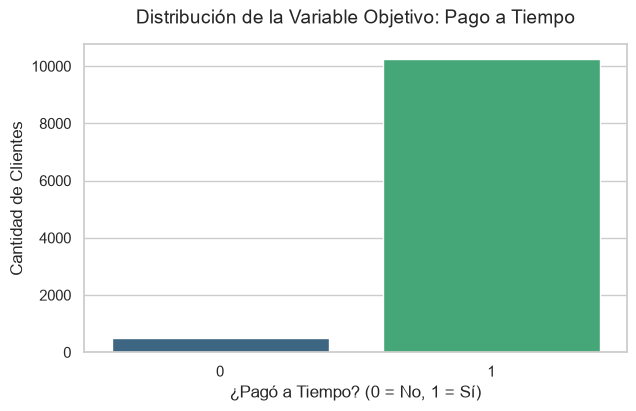

=== CANTIDAD DE CLIENTES POR CATEGORÍA ===
Pago_atiempo
1    10252
0      511
Name: count, dtype: int64

=== PORCENTAJE DEL TOTAL ===
Pago_atiempo
1    95.25
0     4.75
Name: proportion, dtype: float64


In [9]:
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Crear el gráfico de barras
plt.figure(figsize=(7, 4))
sns.countplot(x='Pago_atiempo', data=df, palette='viridis')

plt.title('Distribución de la Variable Objetivo: Pago a Tiempo', fontsize=14, pad=15)
plt.xlabel('¿Pagó a Tiempo? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.show()

# Mostrar los valores numéricos exactos y sus porcentajes
print("=== CANTIDAD DE CLIENTES POR CATEGORÍA ===")
print(df['Pago_atiempo'].value_counts())
print("\n=== PORCENTAJE DEL TOTAL ===")
print(df['Pago_atiempo'].value_counts(normalize=True).round(4) * 100)

In [11]:
print(df.dtypes)

tipo_credito                       int64
capital_prestado                 float64
plazo_meses                        int64
edad_cliente                       int64
tipo_laboral                         str
salario_cliente                    int64
total_otros_prestamos              int64
cuota_pactada                      int64
puntaje                          float64
puntaje_datacredito              float64
cant_creditosvigentes              int64
huella_consulta                    int64
saldo_mora                       float64
saldo_total                      float64
saldo_principal                  float64
saldo_mora_codeudor              float64
creditos_sectorFinanciero          int64
creditos_sectorCooperativo         int64
creditos_sectorReal                int64
promedio_ingresos_datacredito    float64
tendencia_ingresos                   str
Pago_atiempo                       int64
año_prestamo                       int64
mes_prestamo                       int64
dia_prestamo    

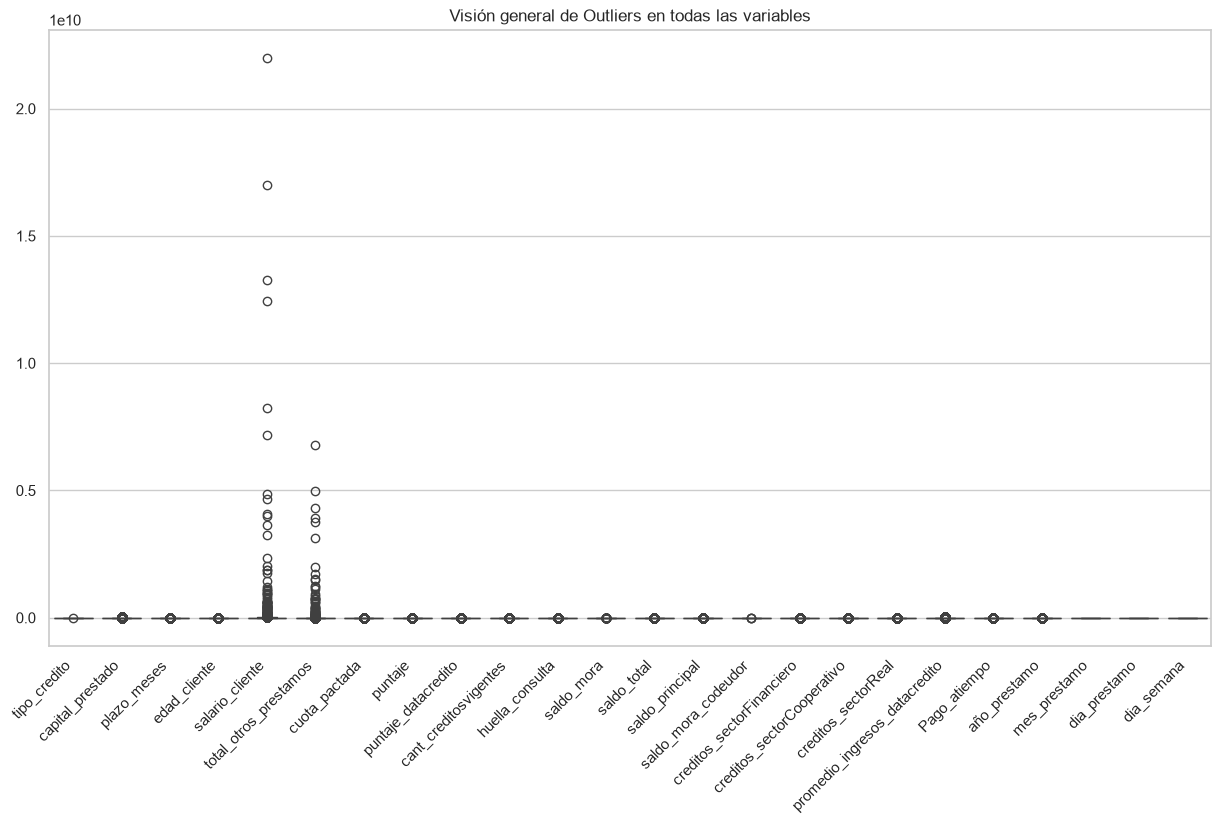

In [13]:
# Configuramos el tamaño de la figura para que no se vea todo amontonado
plt.figure(figsize=(15, 8))

# Seleccionamos solo las columnas numéricas
data_numerica = df.select_dtypes(include=['float64', 'int64'])

# Creamos el boxplot de todas juntas
sns.boxplot(data=data_numerica)
plt.xticks(rotation=45, ha='right')  # Rotamos etiquetas para leerlas bien
plt.title("Visión general de Outliers en todas las variables")
plt.show()

In [14]:
# Definimos las columnas con outliers masivos
cols_outliers = ['salario_cliente', 'total_otros_prestamos']

for col in cols_outliers:
    # Calculamos el límite superior al percentil 99
    p99 = df[col].quantile(0.99)
    # Aplicamos el tope (todo lo que supere el p99, se convierte en el valor del p99)
    df[col] = df[col].clip(upper=p99)

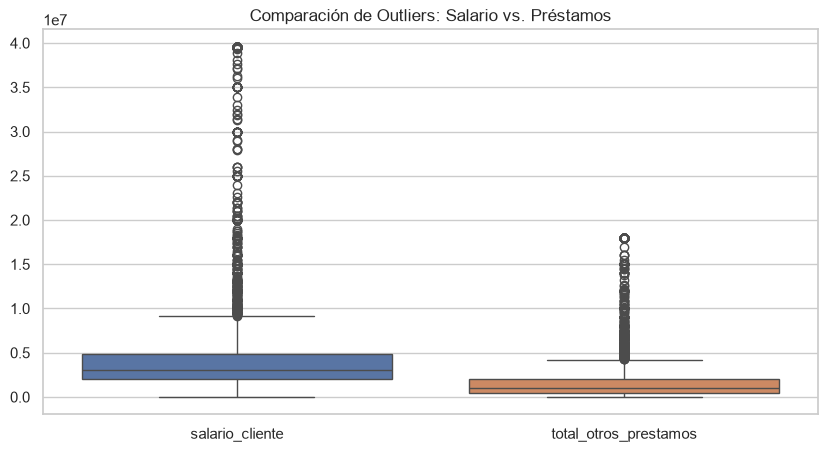

In [15]:
# Graficar ambas columnas para comparar su dispersión
plt.figure(figsize=(10, 5))
data_to_plot = df[['salario_cliente', 'total_otros_prestamos']]
sns.boxplot(data=data_to_plot)
plt.title("Comparación de Outliers: Salario vs. Préstamos")
plt.show()

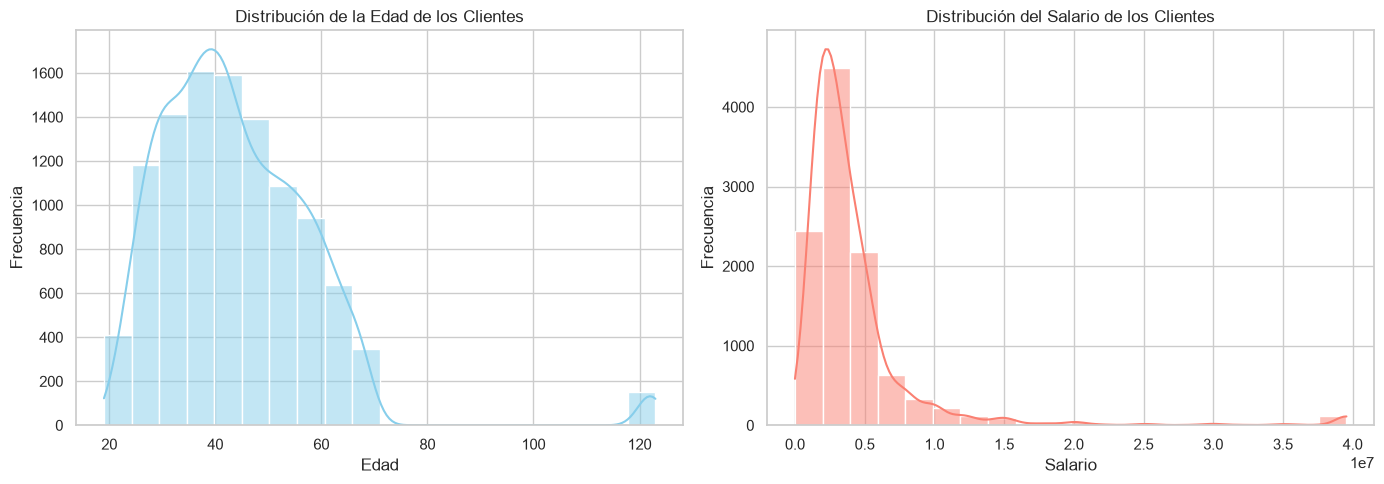

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de Edades
sns.histplot(df['edad_cliente'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de la Edad de los Clientes')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Histograma de Salarios
sns.histplot(df['salario_cliente'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución del Salario de los Clientes')
axes[1].set_xlabel('Salario')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

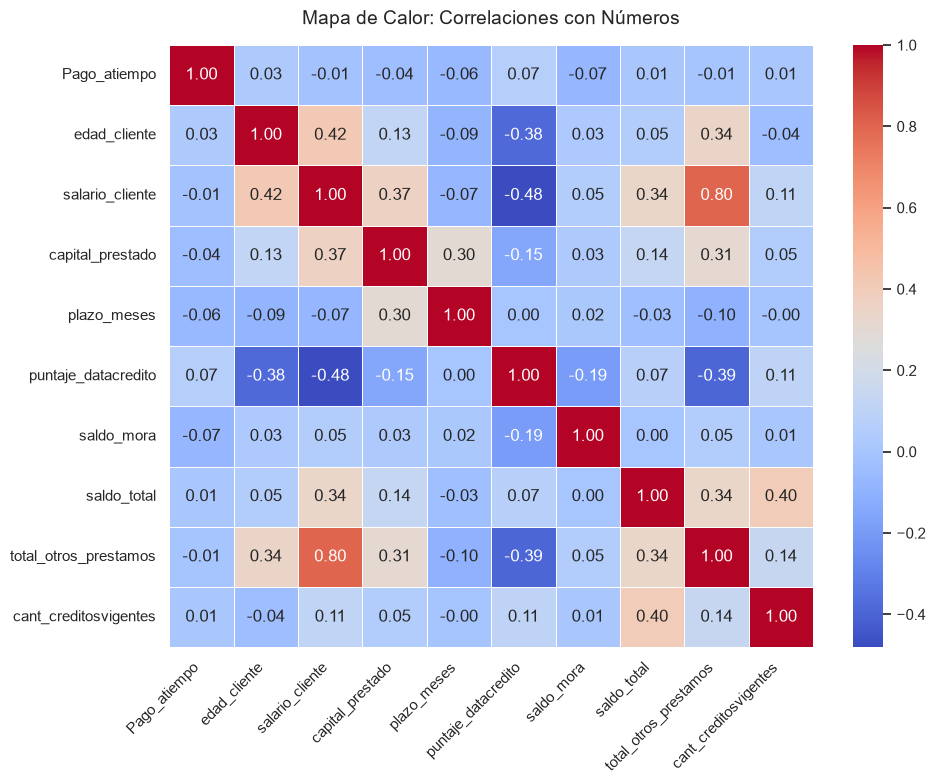

=== TOP CORRELACIONES CON PAGO_ATIEMPO ===
Pago_atiempo                     1.000000
puntaje                          0.923134
puntaje_datacredito              0.067882
promedio_ingresos_datacredito    0.039867
edad_cliente                     0.032252
creditos_sectorFinanciero        0.021390
creditos_sectorCooperativo       0.021267
año_prestamo                     0.020251
saldo_total                      0.014364
saldo_principal                  0.011473
cant_creditosvigentes            0.008829
mes_prestamo                     0.008822
saldo_mora_codeudor              0.002631
tipo_credito                     0.000951
dia_prestamo                    -0.000761
total_otros_prestamos           -0.006463
cuota_pactada                   -0.011814
salario_cliente                 -0.012837
creditos_sectorReal             -0.023306
dia_semana                      -0.033508
capital_prestado                -0.040624
plazo_meses                     -0.063105
saldo_mora                      -

In [19]:
# 1. Seleccionar un grupo de variables clave para que el mapa con números sea legible
variables_clave = [
    'Pago_atiempo', 'edad_cliente', 'salario_cliente', 'capital_prestado', 
    'plazo_meses', 'puntaje_datacredito', 'saldo_mora', 'saldo_total', 
    'total_otros_prestamos', 'cant_creditosvigentes'
]

# 2. Calcular la matriz solo para estas variables
matriz_recortada = df[variables_clave].corr()

# 3. Graficar el mapa de calor con anotaciones numéricas
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_recortada, 
    annot=True,          
    cmap='coolwarm', 
    fmt=".2f",          
    linewidths=0.5, 
    cbar=True
)

plt.title('Mapa de Calor: Correlaciones con Números', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. Mostrar el ranking completo en texto por si querés ver las otras 13 variables
print("=== TOP CORRELACIONES CON PAGO_ATIEMPO ===")
columnas_num = df.select_dtypes(include=['int64', 'float64']).corr()
print(columnas_num['Pago_atiempo'].sort_values(ascending=False))